<a href="https://colab.research.google.com/github/ABHI20-STAT/Differential-Equations-and-Dynamical-Systems/blob/main/Undamped_Pendulam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

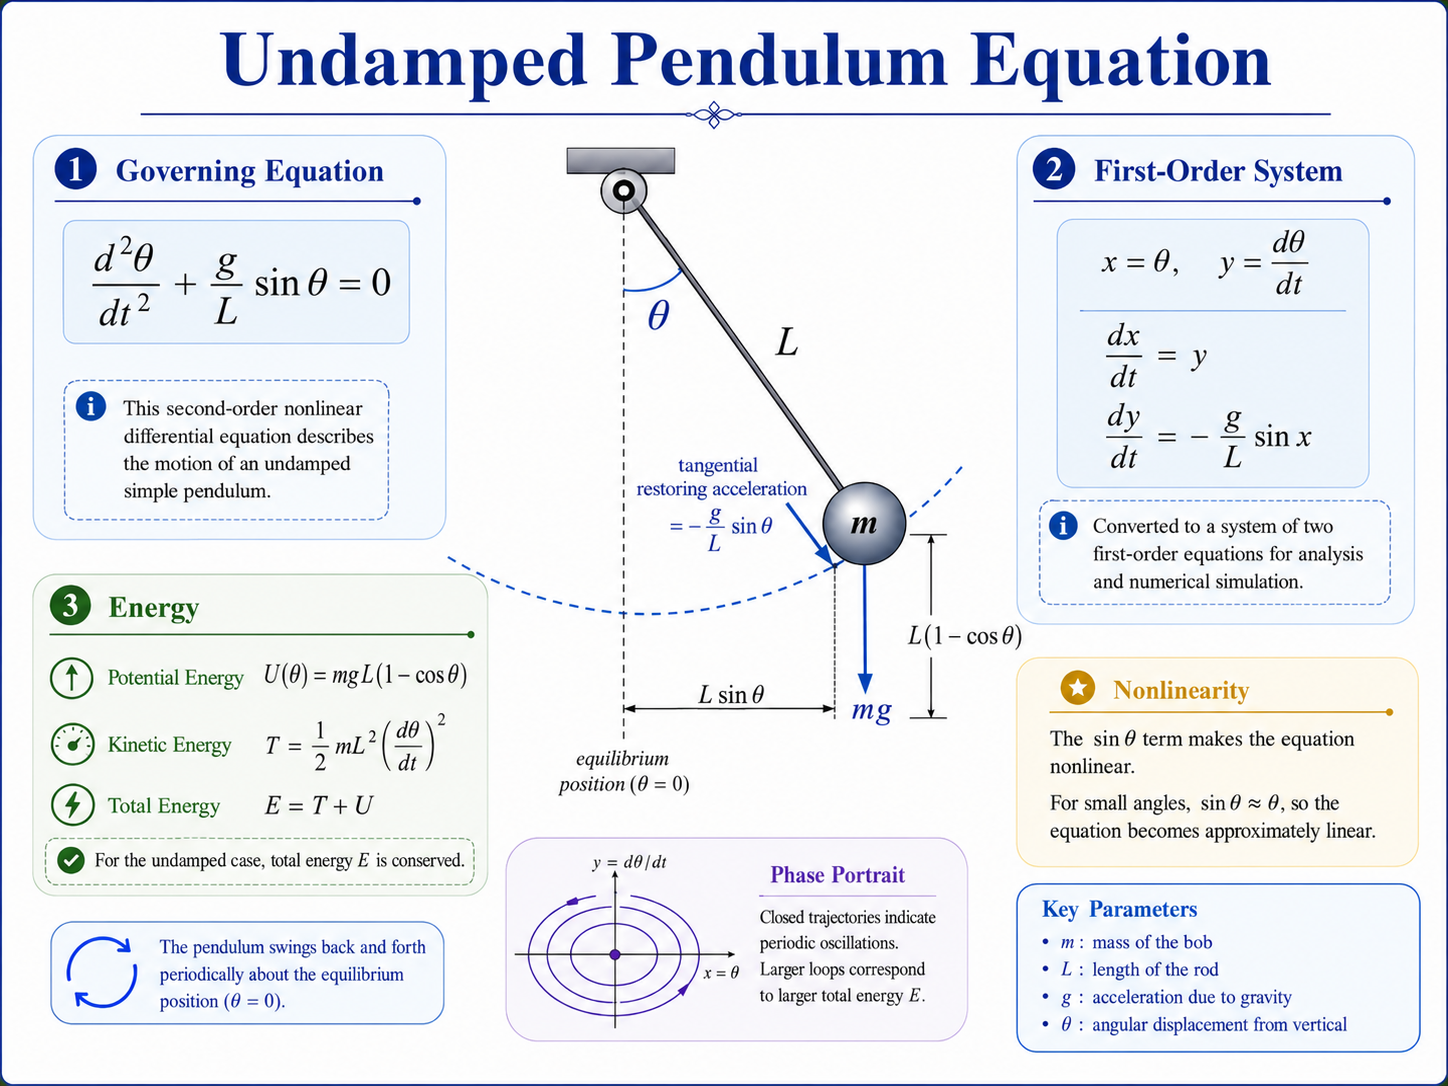

In [ ]:
import numpy as np
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc, FancyArrowPatch, Rectangle
from pathlib import Path


# ============================================================
# 1. Video and Physics Parameters
#    Slower synchronized animation
# ============================================================

video_fps = 8
video_duration = 100.0
slowdown_factor = 2.0

# Physics runs over a shorter interval than video playback,
# so the final animation appears slower.
physics_duration = video_duration / slowdown_factor

n_frames = int(video_fps * video_duration)

physics_dt = 0.01
n_phys = int(physics_duration / physics_dt) + 1

frame_times = np.linspace(0, physics_duration, n_frames)
phys_times = np.linspace(0, physics_duration, n_phys)


# ============================================================
# 2. Physical Parameters
# ============================================================

g = 9.81
L = 1.0
m = 1.0

theta_phys = np.zeros(n_phys)
omega_phys = np.zeros(n_phys)

theta_phys[0] = 1.0
omega_phys[0] = 0.0


# ============================================================
# 3. Pendulum System
# ============================================================

def pendulum_system(th, om):
    dtheta_dt = om
    domega_dt = -(g / L) * np.sin(th)
    return dtheta_dt, domega_dt


# ============================================================
# 4. RK4 Integration on Fine Physics Grid
# ============================================================

for i in range(n_phys - 1):
    th = theta_phys[i]
    om = omega_phys[i]

    k1_th, k1_om = pendulum_system(th, om)

    k2_th, k2_om = pendulum_system(
        th + 0.5 * physics_dt * k1_th,
        om + 0.5 * physics_dt * k1_om
    )

    k3_th, k3_om = pendulum_system(
        th + 0.5 * physics_dt * k2_th,
        om + 0.5 * physics_dt * k2_om
    )

    k4_th, k4_om = pendulum_system(
        th + physics_dt * k3_th,
        om + physics_dt * k3_om
    )

    theta_phys[i + 1] = th + (physics_dt / 6.0) * (
        k1_th + 2 * k2_th + 2 * k3_th + k4_th
    )

    omega_phys[i + 1] = om + (physics_dt / 6.0) * (
        k1_om + 2 * k2_om + 2 * k3_om + k4_om
    )


# ============================================================
# 5. Interpolate Physics onto Video Frame Times
# ============================================================

theta = np.interp(frame_times, phys_times, theta_phys)
omega = np.interp(frame_times, phys_times, omega_phys)

K = 0.5 * m * L**2 * omega**2
U = m * g * L * (1 - np.cos(theta))
E = K + U
E0 = E[0]


# ============================================================
# 6. Colors
# ============================================================

blue = "#173f9a"
gray = "#555555"
green = "#16a34a"
purple = "#6a46b9"
dark = "#111827"

light_blue = "#eaf1ff"
light_green = "#eef9f0"
light_purple = "#f3edff"


# ============================================================
# 7. Figure Layout
#    Adjusted to prevent overlap between Energy and Phase panels
# ============================================================

fig = plt.figure(figsize=(10, 5.8), dpi=100, facecolor="white")

fig.text(
    0.5, 0.965,
    "Undamped Pendulum Equation",
    ha="center",
    va="center",
    fontsize=22,
    color=blue,
    fontweight="bold",
    family="DejaVu Serif"
)

# Governing equation panel
ax_eq1 = fig.add_axes([0.03, 0.71, 0.23, 0.18])

# First-order system panel
ax_eq2 = fig.add_axes([0.27, 0.63, 0.28, 0.23])

# Pendulum panel
ax_pend = fig.add_axes([0.03, 0.12, 0.36, 0.48])

# Phase portrait panel (slightly lower)
ax_phase = fig.add_axes([0.50, 0.09, 0.45, 0.34])

# Energy panel (slightly higher and compact)
ax_energy = fig.add_axes([0.68, 0.56, 0.29, 0.31])


# ============================================================
# 8. Governing Equation Panel
# ============================================================

ax_eq1.axis("off")

ax_eq1.text(
    0.02, 0.88,
    "Governing Equation",
    fontsize=12,
    color=blue,
    fontweight="bold",
    transform=ax_eq1.transAxes
)

ax_eq1.text(
    0.06, 0.40,
    r"$\frac{d^2\theta}{dt^2}+\frac{g}{L}\sin\theta=0$",
    fontsize=16,
    transform=ax_eq1.transAxes,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=light_blue,
        ec="#90b4f8",
        lw=1.0
    )
)


# ============================================================
# 9. First-Order System Panel
# ============================================================

ax_eq2.axis("off")

ax_eq2.text(
    0.05, 0.92,
    "First-Order System",
    fontsize=12,
    color=blue,
    fontweight="bold",
    transform=ax_eq2.transAxes
)

ax_eq2.text(
    0.06, 0.05,
    r"$x=\theta,\quad y=\frac{d\theta}{dt}$"
    "\n\n"
    r"$\frac{dx}{dt}=y,\qquad \frac{dy}{dt}=-\frac{g}{L}\sin x$",
    fontsize=12,
    transform=ax_eq2.transAxes,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=light_blue,
        ec="#90b4f8",
        lw=1.0
    )
)


# ============================================================
# 10. Pendulum Panel
# ============================================================

ax_pend.set_aspect("equal")
ax_pend.set_xlim(-1.35, 1.35)
ax_pend.set_ylim(-1.35, 0.35)
ax_pend.axis("off")

# Support
ax_pend.plot(
    [-0.22, 0.22],
    [0.12, 0.12],
    color="silver",
    lw=8,
    solid_capstyle="round"
)

# Pivot
ax_pend.add_patch(
    Circle((0, 0), 0.06, fc="lightgray", ec="black", lw=1.3, zorder=3)
)
ax_pend.add_patch(
    Circle((0, 0), 0.015, fc="black", ec="black", zorder=4)
)

# Equilibrium line
ax_pend.plot(
    [0, 0],
    [0, -1.15],
    ls="--",
    lw=1.0,
    color="gray",
    alpha=0.7
)

ax_pend.text(
    0,
    -1.22,
    "equilibrium\nposition $(\\theta=0)$",
    ha="center",
    va="top",
    fontsize=9,
    color=gray
)

# Swing path
phi = np.linspace(-1.2, 1.2, 300)
ax_pend.plot(
    np.sin(phi),
    -np.cos(phi),
    ls=(0, (4, 4)),
    color="#3b82f6",
    lw=1.2,
    alpha=0.8
)

# Dynamic pendulum artists
rod_line, = ax_pend.plot([], [], color="#333333", lw=2.5)

bob = Circle(
    (0, -1),
    0.10,
    fc="#9fb6d9",
    ec="#22324b",
    lw=1.8,
    zorder=5
)
ax_pend.add_patch(bob)

bob_label = ax_pend.text(
    0,
    -1,
    "$m$",
    ha="center",
    va="center",
    fontsize=16,
    zorder=6
)

angle_arc = Arc(
    (0, 0),
    0.50,
    0.50,
    angle=0,
    theta1=-90,
    theta2=-60,
    color=blue,
    lw=1.8
)
ax_pend.add_patch(angle_arc)

angle_label = ax_pend.text(
    0.10,
    -0.23,
    "$\\theta$",
    color=blue,
    fontsize=18
)

length_label = ax_pend.text(
    0.25,
    -0.35,
    "$L$",
    fontsize=13
)

# Gravity arrow
mg_arrow = FancyArrowPatch(
    (0, 0),
    (0, 0),
    arrowstyle="-|>",
    mutation_scale=15,
    lw=1.8,
    color="#2563eb"
)
ax_pend.add_patch(mg_arrow)

mg_label = ax_pend.text(
    0,
    0,
    "$mg$",
    color="#2563eb",
    fontsize=14
)

# Restoring angular acceleration arrow
tan_arrow = FancyArrowPatch(
    (0, 0),
    (0, 0),
    arrowstyle="-|>",
    mutation_scale=13,
    lw=1.8,
    color=blue
)
ax_pend.add_patch(tan_arrow)

tan_label = ax_pend.text(
    0.82,
    -0.32,
    "restoring\nangular accel.\n"
    r"$\theta''=-(g/L)\sin\theta$",
    color=blue,
    fontsize=9,
    ha="center"
)

# Geometry helpers
hline, = ax_pend.plot([], [], color="black", lw=0.9)
vdrop, = ax_pend.plot([], [], ls="--", color="gray", lw=0.9)
vert_measure, = ax_pend.plot([], [], color="black", lw=0.9)
vert_cap1, = ax_pend.plot([], [], color="black", lw=0.9)
vert_cap2, = ax_pend.plot([], [], color="black", lw=0.9)

hlabel = ax_pend.text(
    0.25,
    -0.96,
    "$L\\sin\\theta$",
    fontsize=10
)

vlabel = ax_pend.text(
    0.85,
    -0.55,
    "$L(1-\\cos\\theta)$",
    fontsize=10
)


# ============================================================
# 11. Phase Portrait Panel
# ============================================================

ax_phase.set_facecolor(light_purple)

ax_phase.set_title(
    "Phase Portrait",
    fontsize=12,
    color=purple,
    fontweight="bold",
    pad=10
)

ax_phase.set_xlabel(r"$x=\theta$", fontsize=11)
ax_phase.set_ylabel(r"$y=d\theta/dt$", fontsize=11)
ax_phase.grid(alpha=0.25)

mt = 0.2
mo = 0.3

ax_phase.set_xlim(theta.min() - mt, theta.max() + mt)
ax_phase.set_ylim(omega.min() - mo, omega.max() + mo)

# Full reference loop
ax_phase.plot(
    theta,
    omega,
    color="#c4b5fd",
    lw=1.0,
    alpha=0.35
)

phase_line, = ax_phase.plot(
    [],
    [],
    color=purple,
    lw=2.0
)

phase_point, = ax_phase.plot(
    [],
    [],
    "o",
    color=purple,
    ms=6
)

phase_info = ax_phase.text(
    0.02,
    0.96,
    "",
    transform=ax_phase.transAxes,
    ha="left",
    va="top",
    fontsize=8.2,
    color=gray,
    bbox=dict(
        boxstyle="round,pad=0.20",
        fc="white",
        ec="none",
        alpha=0.75
    )
)


# ============================================================
# 12. Energy Balance Panel
#    Row-wise arrangement with clear spacing
# ============================================================

ax_energy.set_facecolor(light_green)
ax_energy.set_xlim(0, 1.05 * E0)
ax_energy.set_ylim(0, 1)
ax_energy.set_xticks([])
ax_energy.set_yticks([])

for spine in ax_energy.spines.values():
    spine.set_visible(False)

ax_energy.set_title(
    "Energy Balance",
    fontsize=13,
    color=green,
    fontweight="bold",
    pad=8
)

# Row 1: Formula
ax_energy.text(
    0.05, 0.92,
    r"$E = T + U$",
    transform=ax_energy.transAxes,
    fontsize=13,
    color=dark,
    fontweight="bold"
)

# Row 2: Explanation lines
ax_energy.text(
    0.05, 0.80,
    "As the bob rises:  U increases, T decreases",
    transform=ax_energy.transAxes,
    fontsize=8.6,
    color=gray
)

ax_energy.text(
    0.05, 0.72,
    "As the bob falls:   U decreases, T increases",
    transform=ax_energy.transAxes,
    fontsize=8.6,
    color=gray
)

# Row 3: Section heading
ax_energy.text(
    0.05, 0.58,
    "Constant total-energy bar",
    transform=ax_energy.transAxes,
    fontsize=9.6,
    color=dark,
    fontweight="bold"
)

# Row 4: Labels above bar
kin_label = ax_energy.text(
    0.14, 0.50,
    "Kinetic $T$",
    transform=ax_energy.transAxes,
    fontsize=9.0,
    color=dark,
    ha="center"
)

pot_label = ax_energy.text(
    0.72, 0.50,
    "Potential $U$",
    transform=ax_energy.transAxes,
    fontsize=9.0,
    color=dark,
    ha="center"
)

# Row 5: Constant total-energy outline
total_outline = Rectangle(
    (0.0, 0.31),
    E0,
    0.15,
    fill=False,
    ec=dark,
    lw=1.2
)
ax_energy.add_patch(total_outline)

# Dynamic stacked bars
bar_K = ax_energy.barh(
    [0.385],
    [K[0]],
    height=0.15,
    color="#22c55e",
    align="center"
)[0]

bar_U = ax_energy.barh(
    [0.385],
    [U[0]],
    left=[K[0]],
    height=0.15,
    color="#60a5fa",
    align="center"
)[0]

# Row 6: Dynamic values in one row
val_T = ax_energy.text(
    0.08, 0.20,
    "",
    transform=ax_energy.transAxes,
    fontsize=8.7,
    color=dark,
    bbox=dict(
        boxstyle="round,pad=0.18",
        fc="white",
        ec="none",
        alpha=0.82
    )
)

val_U = ax_energy.text(
    0.40, 0.20,
    "",
    transform=ax_energy.transAxes,
    fontsize=8.7,
    color=dark,
    bbox=dict(
        boxstyle="round,pad=0.18",
        fc="white",
        ec="none",
        alpha=0.82
    )
)

val_E = ax_energy.text(
    0.72, 0.20,
    "",
    transform=ax_energy.transAxes,
    fontsize=8.7,
    color=dark,
    bbox=dict(
        boxstyle="round,pad=0.18",
        fc="white",
        ec="none",
        alpha=0.82
    )
)

# Row 7: Bottom note
ax_energy.text(
    0.05, 0.06,
    "The total width stays unchanged, so\n"
    "the total mechanical energy is constant.",
    transform=ax_energy.transAxes,
    fontsize=8.0,
    color=gray,
    linespacing=1.30,
    bbox=dict(
        boxstyle="round,pad=0.22",
        fc="white",
        ec="none",
        alpha=0.80
    )
)


# ============================================================
# 13. Render Frames
# ============================================================

frames_dir = Path("pendulum_frames")
frames_dir.mkdir(exist_ok=True)

for file in frames_dir.glob("frame_*.png"):
    file.unlink()

trail_len = min(140, n_frames)

for i in range(n_frames):
    th = theta[i]
    om = omega[i]

    x = L * np.sin(th)
    y = -L * np.cos(th)

    # Pendulum rod and bob
    rod_line.set_data([0, x], [0, y])
    bob.center = (x, y)
    bob_label.set_position((x, y))

    length_label.set_position(
        (0.45 * np.sin(th), -0.45 * np.cos(th) - 0.02)
    )

    # Angle arc update
    deg = np.degrees(th)
    if deg >= 0:
        angle_arc.theta1 = -90
        angle_arc.theta2 = -90 + deg
        angle_label.set_position((0.10, -0.28))
    else:
        angle_arc.theta1 = -90 + deg
        angle_arc.theta2 = -90
        angle_label.set_position((-0.22, -0.28))

    # Gravity arrow update
    mg_arrow.set_positions((x, y), (x, y - 0.48))
    mg_label.set_position((x - 0.03, y - 0.57))

    # Restoring angular acceleration arrow update
    tangent = np.array([np.cos(th), np.sin(th)])
    a_mag = 0.28 * np.tanh(abs((g / L) * np.sin(th)) / 6.0)
    direction = -np.sign(th) if abs(th) > 1e-6 else -1

    tan_arrow.set_positions(
        (x, y),
        tuple(np.array([x, y]) + direction * a_mag * tangent)
    )

    # Geometry lines
    hline.set_data([0, x], [-1.02, -1.02])
    vdrop.set_data([x, x], [-1.02, y])

    hlabel.set_position((x / 2 - 0.10, -0.97))

    xm2 = x + 0.18
    vert_measure.set_data([xm2, xm2], [-1.02, y])
    vert_cap1.set_data([xm2 - 0.03, xm2 + 0.03], [-1.02, -1.02])
    vert_cap2.set_data([xm2 - 0.03, xm2 + 0.03], [y, y])

    vlabel.set_position(
        (xm2 + 0.04, 0.5 * (y - 1.02))
    )

    # Phase portrait with moving trail
    j0 = max(0, i - trail_len)
    phase_line.set_data(theta[j0:i + 1], omega[j0:i + 1])
    phase_point.set_data([th], [om])

    phase_info.set_text(
        f"$\\theta$ = {th:.2f} rad\n"
        f"$\\omega$ = {om:.2f} rad/s\n"
        f"$E$ = {E[i]:.2f}"
    )

    # Energy balance update
    bar_K.set_width(K[i])
    bar_U.set_x(K[i])
    bar_U.set_width(U[i])

    val_T.set_text(f"$T$ = {K[i]:.2f}")
    val_U.set_text(f"$U$ = {U[i]:.2f}")
    val_E.set_text(f"$E$ = {E[i]:.2f}")

    fig.savefig(
        frames_dir / f"frame_{i:04d}.png",
        dpi=100
    )

    if i % 50 == 0:
        print("saved frame", i)

print("Frames saved to:", frames_dir)

print(
    f"\nRun this command to create the video:\n"
    f"ffmpeg -y -framerate {video_fps} "
    f"-i pendulum_frames/frame_%04d.png "
    f"-c:v libx264 -pix_fmt yuv420p "
    f"undamped_pendulum_animation_rowwise_final.mp4"
)

saved frame 0
saved frame 50
saved frame 100
saved frame 150
saved frame 200
saved frame 250
saved frame 300
saved frame 350
saved frame 400
saved frame 450
saved frame 500
saved frame 550
saved frame 600
saved frame 650
saved frame 700
saved frame 750
Frames saved to: pendulum_frames

Run this command to create the video:
ffmpeg -y -framerate 8 -i pendulum_frames/frame_%04d.png -c:v libx264 -pix_fmt yuv420p undamped_pendulum_animation_rowwise_final.mp4


In [ ]:
!ffmpeg -y -framerate 8 -i pendulum_frames/frame_%04d.png -c:v libx264 -pix_fmt yuv420p undamped_pendulum_animation_rowwise_final.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import Video
Video("undamped_pendulum_animation_rowwise_final.mp4", embed=True)

In [ ]:
import numpy as np
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc, FancyArrowPatch
from pathlib import Path


# ============================================================
# 1. Video and Physics Parameters
#    Slow synchronized animation
# ============================================================

video_fps = 8
video_duration = 100.0
slowdown_factor = 2.0

# The final video is longer than the physical evolution,
# so the motion appears slower.
physics_duration = video_duration / slowdown_factor

n_frames = int(video_fps * video_duration)

physics_dt = 0.01
n_phys = int(physics_duration / physics_dt) + 1

frame_times = np.linspace(0, physics_duration, n_frames)
phys_times = np.linspace(0, physics_duration, n_phys)


# ============================================================
# 2. Physical Parameters
# ============================================================

g = 9.81
L = 1.0
m = 1.0

theta_phys = np.zeros(n_phys)
omega_phys = np.zeros(n_phys)

theta_phys[0] = 1.0
omega_phys[0] = 0.0


# ============================================================
# 3. Pendulum System
# ============================================================

def pendulum_system(th, om):
    dtheta_dt = om
    domega_dt = -(g / L) * np.sin(th)
    return dtheta_dt, domega_dt


# ============================================================
# 4. RK4 Integration on a Fine Physics Grid
# ============================================================

for i in range(n_phys - 1):
    th = theta_phys[i]
    om = omega_phys[i]

    k1_th, k1_om = pendulum_system(th, om)

    k2_th, k2_om = pendulum_system(
        th + 0.5 * physics_dt * k1_th,
        om + 0.5 * physics_dt * k1_om
    )

    k3_th, k3_om = pendulum_system(
        th + 0.5 * physics_dt * k2_th,
        om + 0.5 * physics_dt * k2_om
    )

    k4_th, k4_om = pendulum_system(
        th + physics_dt * k3_th,
        om + physics_dt * k3_om
    )

    theta_phys[i + 1] = th + (physics_dt / 6.0) * (
        k1_th + 2 * k2_th + 2 * k3_th + k4_th
    )

    omega_phys[i + 1] = om + (physics_dt / 6.0) * (
        k1_om + 2 * k2_om + 2 * k3_om + k4_om
    )


# ============================================================
# 5. Interpolate Physics onto Video-Frame Times
# ============================================================

theta = np.interp(frame_times, phys_times, theta_phys)
omega = np.interp(frame_times, phys_times, omega_phys)

K = 0.5 * m * L**2 * omega**2
U = m * g * L * (1 - np.cos(theta))
E = K + U
E0 = E[0]


# ============================================================
# 6. Colors
# ============================================================

blue = "#173f9a"
gray = "#555555"
purple = "#6a46b9"

light_blue = "#eaf1ff"
light_purple = "#f3edff"
light_gray = "#f6f7f9"


# ============================================================
# 7. Figure Layout
#    A single top panel contains the full mathematical formulation.
#    Bottom-left: pendulum animation
#    Bottom-right: phase portrait
# ============================================================

fig = plt.figure(figsize=(11.0, 6.3), dpi=100, facecolor="white")

fig.text(
    0.5, 0.972,
    "Undamped Pendulum Equation",
    ha="center",
    va="center",
    fontsize=23,
    color=blue,
    fontweight="bold",
    family="DejaVu Serif"
)

# Single mathematical-formulation panel
# height slightly increased to avoid title overlap
ax_math = fig.add_axes([0.04, 0.55, 0.92, 0.35])

# Pendulum panel
ax_pend = fig.add_axes([0.05, 0.08, 0.38, 0.40])

# Phase portrait panel
ax_phase = fig.add_axes([0.54, 0.11, 0.40, 0.30])


# ============================================================
# 8. Mathematical Formulation Panel
# ============================================================

ax_math.set_facecolor(light_gray)
ax_math.axis("off")

ax_math.text(
    0.01, 0.97,
    "Mathematical Formulation",
    fontsize=14,
    color=blue,
    fontweight="bold",
    va="top"
)

# ----- Row 1 -----

# Newton's second law block
ax_math.text(
    0.02, 0.82,
    "Newton's Second Law",
    fontsize=11.5,
    color=blue,
    fontweight="bold"
)

ax_math.text(
    0.03, 0.60,
    r"$mL\frac{d^2\theta}{dt^2}=-mg\sin\theta$",
    fontsize=14.5,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=light_blue,
        ec="#90b4f8",
        lw=1.0
    )
)

# Governing equation block
ax_math.text(
    0.34, 0.82,
    "Governing Equation",
    fontsize=11.5,
    color=blue,
    fontweight="bold"
)

ax_math.text(
    0.35, 0.60,
    r"$\frac{d^2\theta}{dt^2}+\frac{g}{L}\sin\theta=0$",
    fontsize=14.5,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=light_blue,
        ec="#90b4f8",
        lw=1.0
    )
)

# First-order system block
# moved downward so title is visible
ax_math.text(
    0.65, 0.82,
    "First-Order System",
    fontsize=11.5,
    color=blue,
    fontweight="bold"
)

ax_math.text(
    0.66, 0.42,
    r"$x=\theta,\quad y=\frac{d\theta}{dt}$"
    "\n\n"
    r"$\frac{dx}{dt}=y,\qquad \frac{dy}{dt}=-\frac{g}{L}\sin x$",
    fontsize=13.0,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=light_blue,
        ec="#90b4f8",
        lw=1.0
    )
)

# ----- Row 2 -----

# Potential energy block
ax_math.text(
    0.02, 0.34,
    "Potential Energy",
    fontsize=11.5,
    color=blue,
    fontweight="bold"
)

ax_math.text(
    0.03, 0.13,
    r"$U(x)=mgL(1-\cos x)$",
    fontsize=14.2,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=light_blue,
        ec="#90b4f8",
        lw=1.0
    )
)

# Kinetic energy block
ax_math.text(
    0.35, 0.34,
    "Kinetic Energy",
    fontsize=11.5,
    color=blue,
    fontweight="bold"
)

ax_math.text(
    0.36, 0.13,
    r"$T(y)=\frac{1}{2}mL^2y^2$",
    fontsize=14.2,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=light_blue,
        ec="#90b4f8",
        lw=1.0
    )
)

# ============================================================
# Conserved Total Energy block
#
# ============================================================

ax_math.text(
    0.64, 0.27,
    "Conserved Total Energy",
    fontsize=11.5,
    color=blue,
    fontweight="bold"
)

ax_math.text(
    0.63, -0.02,
    r"$E(x,y)=\frac{1}{2}mL^2y^2+mgL(1-\cos x)$"
    "\n"
    r"$E(x,y)=\mathrm{constant}$",
    fontsize=12.4,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=light_blue,
        ec="#90b4f8",
        lw=1.0
    )
)


# ============================================================
# 9. Pendulum Panel
# ============================================================

ax_pend.set_aspect("equal")
ax_pend.set_xlim(-1.35, 1.35)
ax_pend.set_ylim(-1.35, 0.35)
ax_pend.axis("off")

# Support
ax_pend.plot(
    [-0.22, 0.22],
    [0.12, 0.12],
    color="silver",
    lw=8,
    solid_capstyle="round"
)

# Pivot
ax_pend.add_patch(
    Circle((0, 0), 0.06, fc="lightgray", ec="black", lw=1.3, zorder=3)
)
ax_pend.add_patch(
    Circle((0, 0), 0.015, fc="black", ec="black", zorder=4)
)

# Equilibrium line
ax_pend.plot(
    [0, 0],
    [0, -1.15],
    ls="--",
    lw=1.0,
    color="gray",
    alpha=0.7
)

ax_pend.text(
    0,
    -1.22,
    "equilibrium\nposition $(\\theta=0)$",
    ha="center",
    va="top",
    fontsize=9,
    color=gray
)

# Swing path
phi = np.linspace(-1.2, 1.2, 300)
ax_pend.plot(
    np.sin(phi),
    -np.cos(phi),
    ls=(0, (4, 4)),
    color="#3b82f6",
    lw=1.2,
    alpha=0.8
)

# Dynamic pendulum artists
rod_line, = ax_pend.plot([], [], color="#333333", lw=2.5)

bob = Circle(
    (0, -1),
    0.10,
    fc="#9fb6d9",
    ec="#22324b",
    lw=1.8,
    zorder=5
)
ax_pend.add_patch(bob)

bob_label = ax_pend.text(
    0,
    -1,
    "$m$",
    ha="center",
    va="center",
    fontsize=16,
    zorder=6
)

# Angle arc
angle_arc = Arc(
    (0, 0),
    0.50,
    0.50,
    angle=0,
    theta1=-90,
    theta2=-60,
    color=blue,
    lw=1.8
)
ax_pend.add_patch(angle_arc)

angle_label = ax_pend.text(
    0.10,
    -0.23,
    "$\\theta$",
    color=blue,
    fontsize=18
)

length_label = ax_pend.text(
    0.25,
    -0.35,
    "$L$",
    fontsize=13
)

# Gravity arrow
mg_arrow = FancyArrowPatch(
    (0, 0),
    (0, 0),
    arrowstyle="-|>",
    mutation_scale=15,
    lw=1.8,
    color="#2563eb"
)
ax_pend.add_patch(mg_arrow)

mg_label = ax_pend.text(
    0,
    0,
    "$mg$",
    color="#2563eb",
    fontsize=14
)

# Restoring angular acceleration arrow
tan_arrow = FancyArrowPatch(
    (0, 0),
    (0, 0),
    arrowstyle="-|>",
    mutation_scale=13,
    lw=1.8,
    color=blue
)
ax_pend.add_patch(tan_arrow)

tan_label = ax_pend.text(
    0.82,
    -0.34,   # moved upward from -0.42
    "restoring\nangular accel.\n"
    r"$\theta''=-(g/L)\sin\theta$",
    color=blue,
    fontsize=9,
    ha="center"
)

# Geometry helpers
hline, = ax_pend.plot([], [], color="black", lw=0.9)
vdrop, = ax_pend.plot([], [], ls="--", color="gray", lw=0.9)
vert_measure, = ax_pend.plot([], [], color="black", lw=0.9)
vert_cap1, = ax_pend.plot([], [], color="black", lw=0.9)
vert_cap2, = ax_pend.plot([], [], color="black", lw=0.9)

hlabel = ax_pend.text(
    0.25,
    -0.96,
    "$L\\sin\\theta$",
    fontsize=10
)

vlabel = ax_pend.text(
    0.85,
    -0.55,
    "$L(1-\\cos\\theta)$",
    fontsize=10
)


# ============================================================
# 10. Phase Portrait Panel
# ============================================================

ax_phase.set_facecolor(light_purple)

ax_phase.set_title(
    "Phase Portrait",
    fontsize=12,
    color=purple,
    fontweight="bold",
    pad=10
)

ax_phase.set_xlabel(r"$x=\theta$", fontsize=11)
ax_phase.set_ylabel(r"$y=d\theta/dt$", fontsize=11)
ax_phase.grid(alpha=0.25)

mt = 0.2
mo = 0.3

ax_phase.set_xlim(theta.min() - mt, theta.max() + mt)
ax_phase.set_ylim(omega.min() - mo, omega.max() + mo)

# Full reference loop
ax_phase.plot(
    theta,
    omega,
    color="#c4b5fd",
    lw=1.0,
    alpha=0.35
)

phase_line, = ax_phase.plot(
    [],
    [],
    color=purple,
    lw=2.0
)

phase_point, = ax_phase.plot(
    [],
    [],
    "o",
    color=purple,
    ms=6
)

phase_info = ax_phase.text(
    0.02,
    0.96,
    "",
    transform=ax_phase.transAxes,
    ha="left",
    va="top",
    fontsize=8.2,
    color=gray,
    bbox=dict(
        boxstyle="round,pad=0.20",
        fc="white",
        ec="none",
        alpha=0.75
    )
)


# ============================================================
# 11. Render Frames
# ============================================================

frames_dir = Path("pendulum_frames")
frames_dir.mkdir(exist_ok=True)

for file in frames_dir.glob("frame_*.png"):
    file.unlink()

trail_len = min(140, n_frames)

for i in range(n_frames):
    th = theta[i]
    om = omega[i]

    x = L * np.sin(th)
    y = -L * np.cos(th)

    # Pendulum rod and bob
    rod_line.set_data([0, x], [0, y])
    bob.center = (x, y)
    bob_label.set_position((x, y))

    length_label.set_position(
        (0.45 * np.sin(th), -0.45 * np.cos(th) - 0.02)
    )

    # Angle arc update
    deg = np.degrees(th)
    if deg >= 0:
        angle_arc.theta1 = -90
        angle_arc.theta2 = -90 + deg
        angle_label.set_position((0.10, -0.28))
    else:
        angle_arc.theta1 = -90 + deg
        angle_arc.theta2 = -90
        angle_label.set_position((-0.22, -0.28))

    # Gravity arrow update
    mg_arrow.set_positions((x, y), (x, y - 0.48))
    mg_label.set_position((x - 0.03, y - 0.57))

    # Restoring angular acceleration arrow update
    tangent = np.array([np.cos(th), np.sin(th)])
    a_mag = 0.28 * np.tanh(abs((g / L) * np.sin(th)) / 6.0)
    direction = -np.sign(th) if abs(th) > 1e-6 else -1

    tan_arrow.set_positions(
        (x, y),
        tuple(np.array([x, y]) + direction * a_mag * tangent)
    )

    # Geometry lines
    hline.set_data([0, x], [-1.02, -1.02])
    vdrop.set_data([x, x], [-1.02, y])

    hlabel.set_position((x / 2 - 0.10, -0.97))

    xm2 = x + 0.18
    vert_measure.set_data([xm2, xm2], [-1.02, y])
    vert_cap1.set_data([xm2 - 0.03, xm2 + 0.03], [-1.02, -1.02])
    vert_cap2.set_data([xm2 - 0.03, xm2 + 0.03], [y, y])

    vlabel.set_position((xm2 + 0.04, 0.5 * (y - 1.02)))

    # Phase portrait with moving trail
    j0 = max(0, i - trail_len)
    phase_line.set_data(theta[j0:i + 1], omega[j0:i + 1])
    phase_point.set_data([th], [om])

    phase_info.set_text(
        f"$\\theta$ = {th:.2f} rad\n"
        f"$\\omega$ = {om:.2f} rad/s\n"
        f"$E$ = {E[i]:.2f}"
    )

    fig.savefig(
        frames_dir / f"frame_{i:04d}.png",
        dpi=100
    )

    if i % 50 == 0:
        print("saved frame", i)

print("Frames saved to:", frames_dir)

print(
    f"\nRun this command to create the video:\n"
    f"ffmpeg -y -framerate {video_fps} "
    f"-i pendulum_frames/frame_%04d.png "
    f"-c:v libx264 -pix_fmt yuv420p "
    f"undamped_pendulum_animation_single_math_panel_fixed.mp4"
)

saved frame 0
saved frame 50
saved frame 100
saved frame 150
saved frame 200
saved frame 250
saved frame 300
saved frame 350
saved frame 400
saved frame 450
saved frame 500
saved frame 550
saved frame 600
saved frame 650
saved frame 700
saved frame 750
Frames saved to: pendulum_frames

Run this command to create the video:
ffmpeg -y -framerate 8 -i pendulum_frames/frame_%04d.png -c:v libx264 -pix_fmt yuv420p undamped_pendulum_animation_single_math_panel_fixed.mp4


In [ ]:
!ffmpeg -y -framerate 8 -i pendulum_frames/frame_%04d.png -c:v libx264 -pix_fmt yuv420p undamped_pendulum_animation_single_math_panel_fixed.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import Video
Video("undamped_pendulum_animation_single_math_panel_fixed.mp4", embed=True)